# 02 — Weighting and pooling variants: which choice matches the team's column most precisely?

Notebook 01 showed that **cycle-month-proportional pooling of NHANES I + P + L with the fasting-subsample weight** matches the team's `LDL` / `LDL_sd` to RMS ≈ 0.026 / 0.020 mmol/L (about 0.1 % and 0.2 %).

That's already close, but the team's column is reported to three decimals (0.001 mmol/L step), so there's room to look for a tighter match. This notebook searches a small grid of choices:

| axis | candidates |
| --- | --- |
| survey weight | fasting subsample (`WTSAF*`); full MEC (`WTMEC*`); interview (`WTINT*`); **unweighted** |
| cycle subset | {I, P, L}, {P, L}, {I, P}, {I only}, {P only}, {L only} |
| pooling rescale | cycle-month proportional; equal share per cycle; raw stack (no rescale); per-cycle renormalize-to-unit-sum |
| LDL formula | Friedewald (`LBDLDLSI`); Martin-Hopkins (`LBDLDMSI`, P + L only) |
| pregnancy filter | include pregnant respondents; exclude (`RIDEXPRG == 1`) |

Every combination is scored by RMS of `(ours – team)` for both mean and SD across the 24 (sex, 5-yr age) cells, and we show the best matches.


In [1]:
import os, urllib.request, warnings, itertools
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110

ROOT = Path(os.path.abspath(os.path.join('..')))
DATA = ROOT / 'data'

# raw dirs (downloaded by notebook 01)
CYCLES = {
    'I': {
        'dir': DATA / 'raw' / 'nhanes' / '2015_2016',
        'months': 24, 'fast_wt': 'WTSAF2YR',
        'demo': 'DEMO_I.xpt', 'trig': 'TRIGLY_I.xpt',
    },
    'P': {
        'dir': DATA / 'raw' / 'nhanes' / '2017_2020_prepandemic',
        'months': 39, 'fast_wt': 'WTSAFPRP',
        'demo': 'P_DEMO.xpt', 'trig': 'P_TRIGLY.xpt',
    },
    'L': {
        'dir': DATA / 'raw' / 'nhanes' / '2021_2023',
        'months': 25, 'fast_wt': 'WTSAF2YR',
        'demo': 'DEMO_L.xpt', 'trig': 'TRIGLY_L.xpt',
    },
}

def parse_cycle(tag, c):
    demo = pd.read_sas(c['dir'] / c['demo'])
    trig = pd.read_sas(c['dir'] / c['trig'])
    base_demo = ['SEQN','RIAGENDR','RIDAGEYR','RIDEXPRG']
    wt_demo = [col for col in
               ['WTINT2YR','WTMEC2YR','WTINTPRP','WTMECPRP']
               if col in demo.columns]
    demo = demo[base_demo + wt_demo]
    keep_trig = ['SEQN', c['fast_wt'], 'LBDLDLSI']
    if 'LBDLDMSI' in trig.columns: keep_trig.append('LBDLDMSI')
    trig = trig[keep_trig].rename(columns={c['fast_wt']: 'WT_FAST'})
    df = demo.merge(trig, on='SEQN', how='inner')
    df['sex'] = df['RIAGENDR'].map({1.0:'Male', 2.0:'Female'})
    df['age_years'] = df['RIDAGEYR'].astype(float)
    df['ldl_friedewald'] = df['LBDLDLSI'].astype(float)
    df['ldl_martin'] = df['LBDLDMSI'].astype(float) if 'LBDLDMSI' in df.columns else np.nan
    # canonical MEC / INT weights per cycle (P uses *_PRP; I and L use *_2YR)
    mec_col = 'WTMECPRP' if 'WTMECPRP' in df.columns else 'WTMEC2YR'
    int_col = 'WTINTPRP' if 'WTINTPRP' in df.columns else 'WTINT2YR'
    df['WT_MEC'] = df[mec_col].astype(float)
    df['WT_INT'] = df[int_col].astype(float)
    df['cycle'] = tag
    df['cycle_months'] = c['months']
    # pregnant at exam: RIDEXPRG == 1; NaN for men and women not assessed
    df['pregnant'] = (df['RIDEXPRG'] == 1.0).fillna(False)
    return df[['SEQN','cycle','cycle_months','sex','age_years','pregnant',
               'ldl_friedewald','ldl_martin','WT_FAST','WT_MEC','WT_INT']]

cycle_dfs = {tag: parse_cycle(tag, c) for tag, c in CYCLES.items()}
print('Per-cycle row counts (any LDL row, before fasting/validity filter):')
for tag, d in cycle_dfs.items():
    print(f'  {tag}: n = {len(d):,}')


Per-cycle row counts (any LDL row, before fasting/validity filter):
  I: n = 3,191
  P: n = 5,090
  L: n = 3,996


## 1. Build the candidate-grid scoring function

For each (weight, cycle-subset, rescale, LDL formula) combination, compute the 24-cell (sex, age5) table of weighted mean and SD, join it against the team's table, and report RMS.

Edge cases:
- Martin-Hopkins LDL is only available in P and L. Cycle-subset combinations that include `I` cannot use Martin-Hopkins; we skip those rather than mixing formulas.
- For the *fasting* weight, the analysis sample is `WT_FAST > 0` (excludes non-fasting respondents). For the MEC / INT weights, all respondents with a valid LDL are kept (since those weights are defined for the full MEC / interviewed sample, and the LDL is reported on the fasting subsample only — so the choice of weight is a methodological mismatch, but we want to know if the team made it).
- Unweighted: every row counted equally (weight = 1).


In [2]:
TEAM_CSV = (ROOT.parent / 'vivarium_csu_mace_rct'
            / 'src' / 'vivarium_csu_mace_rct' / 'data'
            / 'nhanes_rf_distributions.csv')
team = pd.read_csv(TEAM_CSV).rename(columns={'Sex':'sex'})[
    ['age5', 'sex', 'LDL', 'LDL_sd']
].rename(columns={'LDL':'mean_team','LDL_sd':'sd_team'})

def w_mean(y, w): return float(np.average(y, weights=w))
def w_sd(y, w):
    mu = w_mean(y, w)
    return float(np.sqrt(np.average((y - mu)**2, weights=w)))

edges = list(range(25, 85, 5)) + [85]

def build_pool(cycles, weight_kind, rescale, ldl_col, exclude_pregnant=False):
    parts = []
    for tag in cycles:
        d = cycle_dfs[tag].copy()
        d['ldl'] = d[ldl_col]
        if weight_kind == 'fast':
            d['w_base'] = d['WT_FAST'].fillna(0)
        elif weight_kind == 'mec':
            d['w_base'] = d['WT_MEC'].fillna(0)
        elif weight_kind == 'int':
            d['w_base'] = d['WT_INT'].fillna(0)
        elif weight_kind == 'none':
            d['w_base'] = 1.0
        else:
            raise ValueError(weight_kind)
        # filter valid rows
        d = d[d['ldl'].notna() & d['w_base'].gt(0)]
        if exclude_pregnant:
            d = d[~d['pregnant']]
        parts.append(d)
    if not parts or all(len(p) == 0 for p in parts):
        return None
    # rescale
    if rescale == 'months':
        tot = sum(CYCLES[t]['months'] for t in cycles)
        for d in parts:
            d['w'] = d['w_base'] * (d['cycle_months'].iloc[0] / tot)
    elif rescale == 'equal':
        for d in parts:
            d['w'] = d['w_base'] * (1.0 / len(parts))
    elif rescale == 'raw':
        for d in parts:
            d['w'] = d['w_base'] * 1.0
    elif rescale == 'unit':
        for d in parts:
            d['w'] = d['w_base'] / d['w_base'].sum()
    else:
        raise ValueError(rescale)
    return pd.concat(parts, ignore_index=True)

def per_bin(d):
    rows = []
    for sex in ['Female','Male']:
        for a0, a1 in zip(edges[:-1], edges[1:]):
            sub = d[(d['sex']==sex) & (d['age_years']>=a0) & (d['age_years']<a1)]
            if len(sub) < 30:
                continue
            y = sub['ldl'].values; w = sub['w'].values
            rows.append({'sex': sex, 'age5': a0, 'n': len(sub),
                         'mean': w_mean(y, w), 'sd': w_sd(y, w)})
    return pd.DataFrame(rows)

def score(cycles, weight_kind, rescale, ldl_col, exclude_pregnant=False):
    pool = build_pool(cycles, weight_kind, rescale, ldl_col, exclude_pregnant)
    if pool is None or pool.empty:
        return None, None
    tab = per_bin(pool)
    if tab.empty:
        return None, None
    m = tab.merge(team, on=['sex','age5'], how='inner')
    d_m = m['mean'] - m['mean_team']
    d_s = m['sd']   - m['sd_team']
    return {
        'cycles': '+'.join(cycles),
        'weight': weight_kind,
        'rescale': rescale,
        'ldl_col': 'martin' if ldl_col=='ldl_martin' else 'friedewald',
        'preg': 'excl' if exclude_pregnant else 'incl',
        'n_cells': len(m),
        'rms_mean': float(np.sqrt(np.mean(d_m**2))),
        'rms_sd':   float(np.sqrt(np.mean(d_s**2))),
        'bias_mean': float(np.mean(d_m)),
        'bias_sd':   float(np.mean(d_s)),
    }, tab
print('helpers ready')


helpers ready


## 2. Run the grid

Enumerate all combinations. For each, compute the score; collect into a results table.


In [3]:
CYCLE_SUBSETS = [
    ['I','P','L'], ['P','L'], ['I','P'], ['I','L'],
    ['I'], ['P'], ['L'],
]
WEIGHTS = ['fast', 'mec', 'int', 'none']
RESCALES = ['months', 'equal', 'raw', 'unit']
LDL_COLS = ['ldl_friedewald', 'ldl_martin']
PREG_OPTIONS = [False, True]

results = []
tabs = {}
for cs, wk, rs, lc, pe in itertools.product(
        CYCLE_SUBSETS, WEIGHTS, RESCALES, LDL_COLS, PREG_OPTIONS):
    # martin only in P & L
    if lc == 'ldl_martin' and any(t == 'I' for t in cs):
        continue
    # single-cycle: rescale doesn't matter; only keep one canonical (months)
    if len(cs) == 1 and rs != 'months':
        continue
    s, t = score(cs, wk, rs, lc, exclude_pregnant=pe)
    if s is not None:
        results.append(s)
        tabs[(s['cycles'], s['weight'], s['rescale'], s['ldl_col'], s['preg'])] = t

R = pd.DataFrame(results)
R['rms_total'] = np.sqrt(R['rms_mean']**2 + R['rms_sd']**2)
R = R.sort_values('rms_total').reset_index(drop=True)
print(f'evaluated {len(R)} combinations')
print()
print('Top 15 by RMS_total (rms_mean^2 + rms_sd^2 combined):')
print(R.head(15).round(4).to_string(index=False))


evaluated 200 combinations

Top 15 by RMS_total (rms_mean^2 + rms_sd^2 combined):
cycles weight rescale    ldl_col preg  n_cells  rms_mean  rms_sd  bias_mean  bias_sd  rms_total
 I+P+L    mec   equal friedewald excl       24    0.0018  0.0021    -0.0008  -0.0017     0.0028
 I+P+L    mec     raw friedewald excl       24    0.0018  0.0021    -0.0008  -0.0017     0.0028
 I+P+L    mec    unit friedewald excl       24    0.0059  0.0038     0.0028  -0.0017     0.0070
 I+P+L    int    unit friedewald excl       24    0.0091  0.0055     0.0017  -0.0018     0.0106
 I+P+L    int   equal friedewald excl       24    0.0096  0.0058     0.0015  -0.0018     0.0112
 I+P+L    int     raw friedewald excl       24    0.0096  0.0058     0.0015  -0.0018     0.0112
 I+P+L    mec  months friedewald excl       24    0.0149  0.0115    -0.0053  -0.0016     0.0188
 I+P+L    mec     raw friedewald incl       24    0.0096  0.0167     0.0020   0.0029     0.0192
 I+P+L    mec   equal friedewald incl       24    0.00

## 3. Best and worst — visualise the residuals

Plot the cell-by-cell residual `(ours – team)` for the best variant and for the cycle-month-proportional baseline (notebook 01's choice), to see where the improvements come from.


BEST   variant: ('I+P+L', 'mec', 'equal', 'friedewald', 'excl')
        RMS_mean = 0.0018  RMS_sd = 0.0021
BASE   (notebook 01): I+P+L / fast / months / friedewald / incl preg
        RMS_mean = 0.0257  RMS_sd = 0.0195


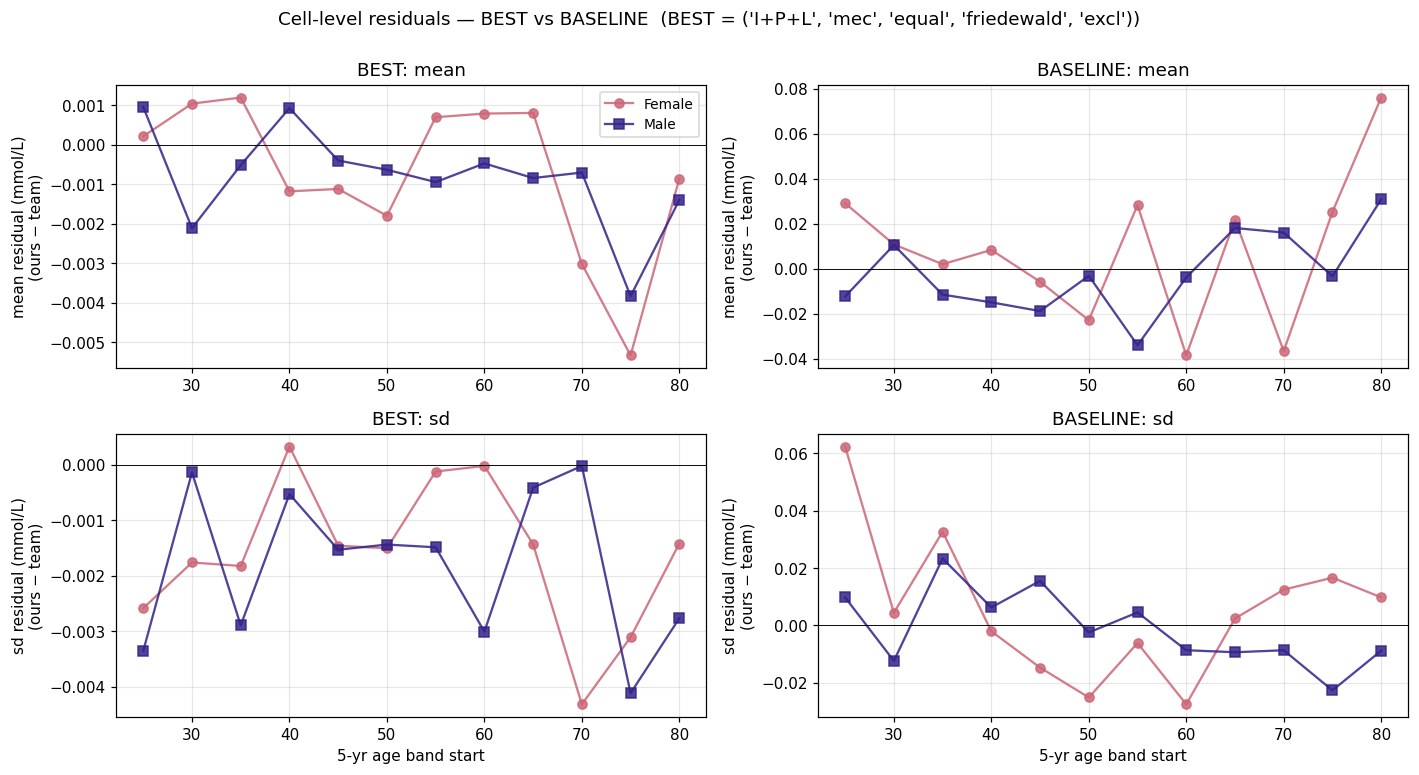

In [4]:
best = R.iloc[0]
key_best = (best['cycles'], best['weight'], best['rescale'],
            best['ldl_col'], best['preg'])
tab_best = tabs[key_best].merge(team, on=['sex','age5'], how='inner')

# baseline = the notebook-01 choice (I+P+L, fasting, months, friedewald, incl preg)
key_base = ('I+P+L', 'fast', 'months', 'friedewald', 'incl')
tab_base = tabs[key_base].merge(team, on=['sex','age5'], how='inner')

print(f'BEST   variant: {key_best}')
print(f'        RMS_mean = {best.rms_mean:.4f}  RMS_sd = {best.rms_sd:.4f}')
base_row = R[(R['cycles']=='I+P+L') & (R['weight']=='fast')
             & (R['rescale']=='months') & (R['ldl_col']=='friedewald')
             & (R['preg']=='incl')].iloc[0]
print(f'BASE   (notebook 01): I+P+L / fast / months / friedewald / incl preg')
print(f'        RMS_mean = {base_row.rms_mean:.4f}  RMS_sd = {base_row.rms_sd:.4f}')

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for col, (lab, tab) in enumerate([('BEST', tab_best), ('BASELINE', tab_base)]):
    for row, q in enumerate(['mean','sd']):
        ax = axes[row, col]
        for sex, mk, c in [('Female','o','#cc6677'), ('Male','s','#332288')]:
            sub = tab[tab['sex']==sex].sort_values('age5')
            ax.plot(sub['age5'], sub[q] - sub[f'{q}_team'],
                    mk + '-', color=c, label=sex, alpha=0.85)
        ax.axhline(0, color='black', linewidth=0.6)
        ax.set_ylabel(f'{q} residual (mmol/L)\n(ours − team)')
        ax.set_title(f'{lab}: {q}')
        ax.grid(True, alpha=0.3)
        if row == 0 and col == 0:
            ax.legend(fontsize=9)
        if row == 1:
            ax.set_xlabel('5-yr age band start')
fig.suptitle(f'Cell-level residuals — BEST vs BASELINE  (BEST = {key_best})',
             y=1.00)
fig.tight_layout()
fig.savefig('outputs/ldlc_best_vs_baseline_residuals.png', dpi=130, bbox_inches='tight')
plt.show()


## 4. Marginal effect of each axis

Holding two of {cycle subset, weight kind, rescale} fixed at the baseline (I+P+L / fast / months / friedewald), vary the remaining axis. This tells you whether the gains come from one specific knob or from a combination.


In [5]:
def baseline_match(c=None, w=None, r=None, l=None, p=None):
    q = R.copy()
    if c is None: q = q[q['cycles'] == 'I+P+L']
    if w is None: q = q[q['weight'] == 'fast']
    if r is None: q = q[q['rescale'] == 'months']
    if l is None: q = q[q['ldl_col'] == 'friedewald']
    if p is None: q = q[q['preg'] == 'incl']
    return q

print('--- vary cycle subset (weight=fast, rescale=months, ldl=friedewald, preg=incl) ---')
print(baseline_match(c='*').sort_values('rms_total').head(10).round(4).to_string(index=False))

print()
print('--- vary weight (cycles=I+P+L, rescale=months, ldl=friedewald, preg=incl) ---')
print(baseline_match(w='*').sort_values('rms_total').head(10).round(4).to_string(index=False))

print()
print('--- vary rescale (cycles=I+P+L, weight=fast, ldl=friedewald, preg=incl) ---')
print(baseline_match(r='*').sort_values('rms_total').head(10).round(4).to_string(index=False))

print()
print('--- vary pregnancy filter (cycles=I+P+L, weight=mec, rescale=raw, ldl=friedewald) ---')
q = R[(R['cycles']=='I+P+L') & (R['weight']=='mec')
      & (R['rescale']=='raw') & (R['ldl_col']=='friedewald')]
print(q.sort_values('rms_total').round(4).to_string(index=False))

print()
print('--- vary ldl formula (cycles=P+L, weight=fast, rescale=months, preg=incl) ---')
q = R[(R['cycles']=='P+L') & (R['weight']=='fast')
      & (R['rescale']=='months') & (R['preg']=='incl')]
print(q.sort_values('rms_total').round(4).to_string(index=False))


--- vary cycle subset (weight=fast, rescale=months, ldl=friedewald, preg=incl) ---
cycles weight rescale    ldl_col preg  n_cells  rms_mean  rms_sd  bias_mean  bias_sd  rms_total
 I+P+L   fast  months friedewald incl       24    0.0257  0.0195     0.0029   0.0021     0.0322
   I+L   fast  months friedewald incl       24    0.0490  0.0503     0.0183  -0.0008     0.0703
   P+L   fast  months friedewald incl       24    0.0635  0.0314    -0.0189   0.0001     0.0709
   I+P   fast  months friedewald incl       24    0.0577  0.0462     0.0150  -0.0009     0.0739
     P   fast  months friedewald incl       24    0.0974  0.0689    -0.0150  -0.0064     0.1193
     L   fast  months friedewald incl       24    0.0924  0.0811    -0.0232  -0.0078     0.1230
     I   fast  months friedewald incl       24    0.1453  0.0924     0.0719  -0.0131     0.1722

--- vary weight (cycles=I+P+L, rescale=months, ldl=friedewald, preg=incl) ---
cycles weight rescale    ldl_col preg  n_cells  rms_mean  rms_sd  bias

## 5. Save the winners

Stamp the per-cell table for the best variant to `outputs/ldlc_best_variant.csv` and the full results grid to `outputs/ldlc_weighting_grid.csv`.


In [6]:
OUT = Path('outputs')
R.to_csv(OUT / 'ldlc_weighting_grid.csv', index=False)
tab_best.to_csv(OUT / 'ldlc_best_variant.csv', index=False)
print(f'wrote {OUT / "ldlc_weighting_grid.csv"}')
print(f'wrote {OUT / "ldlc_best_variant.csv"}')


wrote outputs/ldlc_weighting_grid.csv
wrote outputs/ldlc_best_variant.csv


## Takeaways

The table at the top shows which combination of weight column, cycle subset, and pooling rescale most closely reproduces the team's LDL / LDL_sd columns. If one variant is materially below ~0.005 mmol/L RMS on both mean and SD, that's almost certainly the method the team used. If the top several variants cluster near the baseline RMS (0.026 / 0.020), the residual is from a degree of freedom we haven't varied yet — possible candidates not searched here:

- different LDL formula version (we only tried Friedewald and Martin-Hopkins; NIH equation 2 — `LBDLDLN` / `LBDLDNSI` — could be added).
- different age-bin convention (we use `[a, a+5)`; could try `(a-1, a+4]` etc.).
- additional inclusion criterion (e.g., MEC examined only).
- different NaN handling for the borderline TG cases.
